# Phần 1. NumPy trong workflow ML/DL

Các bài dưới đây dùng dữ liệu nhỏ để mô phỏng preprocessing, inference và xử lý
tensor trong một pipeline thực tế.

In [71]:
STUDENT_NAME = "Dương Nghiệp Phát"  # TODO: Họ và tên
STUDENT_ID = "2550181"    # TODO: MSSV

print(f"Student: {STUDENT_NAME} ({STUDENT_ID})")

Student: Dương Nghiệp Phát (2550181)


In [72]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (8, 4.8)

DATA_CANDIDATES = [
    Path("week02/numpy-pandas-eda-hw/data/automobile_raw.csv"),
    Path("data/automobile_raw.csv"),
    Path("../data/automobile_raw.csv"),
]
DATA_PATH = next((path for path in DATA_CANDIDATES if path.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("Không tìm thấy data/automobile_raw.csv")

print("Data path:", DATA_PATH.resolve())

Data path: C:\Users\Wingery\Downloads\mliot-pyml-2026-hw\week02\numpy-pandas-eda-hw\data\automobile_raw.csv


## N1. Stable softmax cho batch logits

Một classifier trả về `logits` có shape `(batch_size, num_classes)`. Tính softmax
theo từng mẫu bằng cách trừ giá trị lớn nhất trên mỗi hàng trước khi gọi `np.exp`.
Cách viết này tránh overflow khi logits có giá trị lớn.

**Biến đầu ra bắt buộc**

- `shifted_logits`: logits sau khi trừ row-wise maximum.
- `class_probabilities`: xác suất mỗi class, mỗi hàng có tổng bằng 1.
- `predicted_classes`: class có xác suất lớn nhất của từng mẫu.
- `confidence_scores`: xác suất lớn nhất của từng mẫu.

In [73]:
logits = np.array([
    [2.0, 1.0, 0.1],
    [1000.0, 1001.0, 999.0],
    [-2.0, -1.0, 3.0],
    [0.5, 0.5, 0.5],
], dtype=np.float64)

In [74]:
# TODO N1
# shifted_logits = ...
shifted_logits = logits - np.max(logits, axis=-1, keepdims=True)
# exp_logits = ...
exp_logits = np.exp(shifted_logits)
print(f"logits : \n {exp_logits} \n ")
# class_probabilities = ...
class_probabilities = exp_logits / np.sum(exp_logits, axis=-1, keepdims=True)
print(f"Class prob : \n {class_probabilities} \n")
# predicted_classes = ...
predicted_classes = np.argmax(class_probabilities, axis=-1)
print(f"Predicted classes : \n {predicted_classes} \n ")
# confidence_scores = ...
confidence_scores = np.max(class_probabilities, axis=-1)
print(f"Confidence : \n {confidence_scores}")


logits : 
 [[1.         0.36787944 0.14956862]
 [0.36787944 1.         0.13533528]
 [0.00673795 0.01831564 1.        ]
 [1.         1.         1.        ]] 
 
Class prob : 
 [[0.65900114 0.24243297 0.09856589]
 [0.24472847 0.66524096 0.09003057]
 [0.00657326 0.01786798 0.97555875]
 [0.33333333 0.33333333 0.33333333]] 

Predicted classes : 
 [0 1 2 0] 
 
Confidence : 
 [0.65900114 0.66524096 0.97555875 0.33333333]


In [75]:
required = [
    "shifted_logits",
    "class_probabilities",
    "predicted_classes",
    "confidence_scores",
]
if not all(name in globals() for name in required):
    print("Complete N1 to run this self-check.")
else:
    assert class_probabilities.shape == logits.shape
    assert np.all(np.isfinite(class_probabilities))
    assert np.allclose(class_probabilities.sum(axis=1), 1.0)
    assert predicted_classes.shape == (logits.shape[0],)
    assert confidence_scores.shape == (logits.shape[0],)
    print("N1 self-check passed")

N1 self-check passed


## N2. Chuẩn hóa train và validation không gây leakage

Mỗi hàng là một mẫu, mỗi cột là một feature. Tính mean/std **chỉ từ `X_train`**,
sau đó dùng cùng thống kê để transform cả train và validation.

**Biến đầu ra bắt buộc**

- `train_feature_mean`, `train_feature_std`: shape `(4,)`.
- `X_train_scaled`: train set đã chuẩn hóa.
- `X_val_scaled`: validation set dùng thống kê từ train.

In [76]:
# Features: height_cm, weight_kg, activity_hours, age
X_train = np.array([
    [170.0, 65.0, 1.2, 22.0],
    [180.0, 80.0, 2.4, 35.0],
    [160.0, 50.0, 0.8, 19.0],
    [175.0, 70.0, 1.5, 28.0],
    [168.0, 60.0, 1.0, 24.0],
    [182.0, 90.0, 3.0, 41.0],
])

X_val = np.array([
    [172.0, 68.0, 1.4, 26.0],
    [190.0, 95.0, 3.4, 45.0],
])

In [77]:
# TODO N2
print(f"shape: \n {X_train.shape} \n")
# train_feature_mean = ...
train_feature_mean = X_train.mean(axis=0)
print(f"Train mean: \n {train_feature_mean} \n")
# train_feature_std = ...
train_feature_std = X_train.std(axis=0)
print(f"Train std: \n {train_feature_std} \n")
# X_train_scaled = ...
X_train_scaled = (X_train - train_feature_mean) / train_feature_std
print(f"Train z score: \n {X_train_scaled} \n")
# X_val_scaled = ...
X_val_scaled = (X_val - train_feature_mean) / train_feature_std
print(f"Val z score: \n {X_val_scaled} \n")


shape: 
 (6, 4) 

Train mean: 
 [172.5         69.16666667   1.65        28.16666667] 

Train std: 
 [ 7.47774476 13.04372987  0.79109629  7.64671316] 

Train z score: 
 [[-0.3343254  -0.31943828 -0.56883088 -0.80644671]
 [ 1.0029762   0.83053953  0.94805147  0.89363014]
 [-1.671627   -1.4694161  -1.07445834 -1.19877214]
 [ 0.3343254   0.06388766 -0.18961029 -0.02179586]
 [-0.60178572 -0.70276422 -0.82164461 -0.54489643]
 [ 1.27043652  1.59719141  1.70649265  1.67828099]] 

Val z score: 
 [[-0.06686508 -0.08944272 -0.31601716 -0.28334614]
 [ 2.34027779  1.98051735  2.21212011  2.20138156]] 



In [78]:
required = [
    "train_feature_mean",
    "train_feature_std",
    "X_train_scaled",
    "X_val_scaled",
]
if not all(name in globals() for name in required):
    print("Complete N2 to run this self-check.")
else:
    assert X_train_scaled.shape == X_train.shape
    assert X_val_scaled.shape == X_val.shape
    assert np.allclose(X_train_scaled.mean(axis=0), 0.0)
    assert np.allclose(X_train_scaled.std(axis=0), 1.0)
    print("N2 self-check passed")

N2 self-check passed


## N3. Tạo review queue sau inference

Giả sử `class_probabilities` đến từ N1. Một prediction cần được kiểm tra thủ công
nếu dự đoán sai **hoặc** confidence nhỏ hơn `0.70`.

**Biến đầu ra bắt buộc**

- `correct_mask`
- `high_confidence_mask`
- `review_mask`
- `review_indices`

In [79]:
true_labels = np.array([0, 2, 2, 1])
confidence_threshold = 0.70

In [80]:
# TODO N3
# correct_mask = ...
correct_mask = (predicted_classes == true_labels)
print(correct_mask)
# high_confidence_mask = ...
high_confidence_mask = confidence_scores > confidence_threshold
print(high_confidence_mask)
# review_mask = ...
review_mask = (high_confidence_mask == False) | (correct_mask == False)
print(review_mask)
# review_indices = ...
review_indices = np.where(review_mask)[0]
print(review_indices)


[ True False  True False]
[False False  True False]
[ True  True False  True]
[0 1 3]


## N4. Tiền xử lý và augment một batch ảnh

`image_batch_uint8` có layout `(B, H, W, C)`. Chuyển batch về `float32` trong đoạn
`[0, 1]`, sau đó tạo một batch mới được flip ngang. Batch augment phải có bộ nhớ
độc lập để việc chỉnh sửa không làm thay đổi batch đã normalize.

Sau khi tạo batch augment, đặt pixel `augmented_batch[0, 0, 0, 0] = 1.0`.

**Biến đầu ra bắt buộc:** `normalized_batch`, `augmented_batch`.

In [81]:
np.random.seed(3141)

In [82]:
image_batch_uint8 = (
    np.arange(2 * 4 * 4 * 3, dtype=np.uint8)
    .reshape(2, 4, 4, 3)
)

In [83]:
# TODO N4
# normalized_batch = ...
normalized_batch = image_batch_uint8.astype(np.float32) / 255.0
print(normalized_batch.shape)
# augmented_batch = ...
augmented_batch = np.flip(normalized_batch, axis=2).copy()
print(augmented_batch[0, 0, 0, 0])
# augmented_batch[0, 0, 0, 0] = ...
augmented_batch[0, 0, 0, 0] = 1.0
print(augmented_batch[0, 0, 0, 0])


(2, 4, 4, 3)
0.03529412
1.0


# Phần 2. EDA với Automobile

Đọc `data/data_dictionary.md` trước khi xử lý.

## Câu hỏi mở đầu

1. Mỗi dòng đại diện cho đối tượng gì?
2. Ký hiệu missing value trong CSV là gì?
3. `symboling` có ý nghĩa gì?


- mỗi dòng đại diện cho một mẫu xe hơi và các thông số kỹ thuật của xe 
- Các dữ liệu bị thiếu hoặc không xác định được ký hiệu bằng dấu hỏi chấm `?`
- symboling là than đo rủi ro. VD xe +3 là dễ gặp tai nạn -3 là ko gặp


## D1. Load và inspect raw CSV

Load dữ liệu sao cho dấu `?` vẫn là chuỗi để quan sát ảnh hưởng tới dtype.

**Biến đầu ra bắt buộc**

- `raw_df`: DataFrame raw.
- `raw_shape`: tuple.
- `raw_missing_marker_count`: tổng số dấu `?`.

In [84]:
# TODO D1
raw_df = pd.read_csv(DATA_PATH)
raw_shape = raw_df.shape
raw_missing_marker_count = (raw_df == "?").sum().sum()

raw_df.head

<bound method NDFrame.head of      symboling normalized_losses         make fuel_type aspiration num_doors  \
0            3                 ?  alfa-romero       gas        std       two   
1            3                 ?  alfa-romero       gas        std       two   
2            1                 ?  alfa-romero       gas        std       two   
3            2               164         audi       gas        std      four   
4            2               164         audi       gas        std      four   
..         ...               ...          ...       ...        ...       ...   
200         -1                95        volvo       gas        std      four   
201         -1                95        volvo       gas      turbo      four   
202         -1                95        volvo       gas        std      four   
203         -1                95        volvo    diesel      turbo      four   
204         -1                95        volvo       gas      turbo      four   

      bod

## D2. Missing values và dtype

1. Thay `?` bằng `np.nan`.
2. Chuyển các cột trong `NUMERIC_COLUMNS` bằng `pd.to_numeric`.
3. Tạo báo cáo missing.

**Biến đầu ra bắt buộc:** `df_clean`, `missing_by_column`.

In [85]:
NUMERIC_COLUMNS = ['symboling', 'normalized_losses', 'wheel_base', 'length', 'width', 'height', 'curb_weight', 'engine_size', 'bore', 'stroke', 'compression_ratio', 'horsepower', 'peak_rpm', 'city_mpg', 'highway_mpg', 'price']

In [86]:
# TODO D2
df_clean = raw_df.replace("?", np.nan)
for column in NUMERIC_COLUMNS:
    df_clean[column] = pd.to_numeric(df_clean[column])
    
missing_by_column = df_clean.isna().sum()


### Giải thích cách làm sạch dữ liệu

- Vì sao không nên fill tất cả numeric columns bằng cùng một giá trị?
- Với `price`, lựa chọn drop hay fill phù hợp hơn cho bài EDA này? Vì sao?
- `normalized_losses` thiếu nhiều dữ liệu hơn các cột khác. Điều này ảnh hưởng thế nào?

- Điền cùng một giá trị là vô nghĩa. giả sử ta có giá tiền với piston thì rõ ràng hai đại lượng này khác nhau với số đo nên điền cùng 1 số là sai chắc 

- Với biến mục tiêu quan trọng như giá xe, việc drop 4 dòng thiếu là lựa chọn sạch sẽ nhất. Điền bừa (như dùng giá trung bình) sẽ làm lu mờ đi sự khác biệt thực tế giữa xe bình dân và xe sang.
- giá xe là biến quan trọng và là biến dùng để phân biệt giữa các loại xe, vì vậy nếu ta fill bằng mean hay median thì sẽ làm ảnh hưởng tới sự phân biệt đó. Ngoài ra ta cùng không biết chắc chắn là giá xe đó có phù hợp cho các xe đang fill hay không lỡ như nhầm xe sang thành xe rẻ tiền thì sai lệch số liệu

- normalized_losses thiếu đến 20% dữ liệu. nên việc phân tích sẽ bị bias nặng nếu ta phân tích và sử dụng trực tiếp cột này. lý do là thiếu quá nhiều xe có thể dẫn tới không thể hiện được trend toàn cục mà mô hình có thể bị overfit. VD như nhóm xe có rủi ro cao nhg ko được báo cáo 

## D3. DataFrame sang NumPy

Dùng sáu cột trong `AUTO_FEATURES`. Drop các dòng thiếu ít nhất một trong
sáu cột, sau đó chuyển sang `float64` NumPy array và chuẩn hóa theo feature.

**Biến đầu ra bắt buộc**

- `analysis_df`
- `X_auto`
- `auto_feature_mean`
- `auto_feature_std`
- `X_auto_scaled`

In [87]:
AUTO_FEATURES = ['curb_weight', 'engine_size', 'horsepower', 'city_mpg', 'highway_mpg', 'price']

In [88]:
# TODO D3
analysis_df = df_clean[AUTO_FEATURES].dropna()
X_auto = analysis_df.values.astype(np.float64)
auto_feature_mean = X_auto.mean(axis=0)
auto_feature_std = X_auto.std(axis=0)
X_auto_scaled = (X_auto - auto_feature_mean) / auto_feature_std


## D4. Outlier theo price z-score

Tính z-score của `price` bằng NumPy. Một dòng được xem là outlier trong bài
này khi `abs(z) > 2`.

**Biến đầu ra bắt buộc:** `price_z`, `price_outlier_mask`, `price_outliers`.

In [89]:
# TODO D4
price_index = AUTO_FEATURES.index('price')
price_z = X_auto_scaled[:, price_index]

price_outlier_mask = np.abs(price_z) > 2
price_outliers = analysis_df[price_outlier_mask]


## D5. Correlation và GroupBy

**Biến đầu ra bắt buộc**

- `engine_price_corr`: Pearson correlation tính bằng NumPy.
- `price_by_body_style`: Series mean price theo `body_style`, sort index.

In [90]:
# TODO D5
engine_price_corr = np.corrcoef(X_auto[:, AUTO_FEATURES.index('engine_size')], 
                                X_auto[:, AUTO_FEATURES.index('price')])[0, 1]

price_by_body_style = df_clean.groupby('body_style')['price'].mean().sort_index()


# Phần 3. Visualization và insight

Mỗi biểu đồ cần:

1. một câu hỏi;
2. title, axis labels và unit;
3. lựa chọn chart phù hợp;
4. 1--2 câu nhận xét ngay dưới chart.

## M2.1 Price phân phối như thế nào?

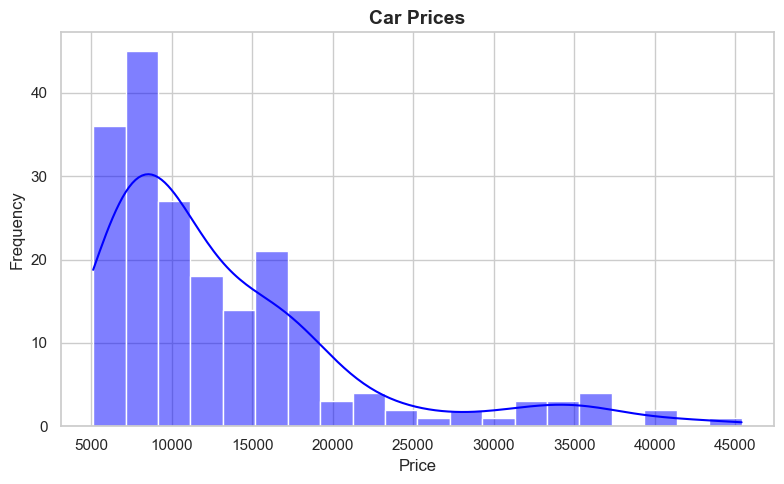

In [91]:
plt.figure(figsize=(8, 5))
sns.histplot(df_clean['price'].dropna(), kde=True, color='blue', bins=20)
plt.title('Car Prices', fontsize=14, fontweight='bold')
plt.xlabel('Price', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.tight_layout()
plt.show()


 Biểu đồ cho thấy phần lớn xe hơi thời đó là xe bình dân với mức giá phổ biến dưới 15000. Ngoài ra việc đường cong phẳng dần khi giá tiến -> 45000 cho thấy các xe có giá thành cao rất không phổ biến

## M2.2 Dataset có cân bằng theo body style không?

C:\Users\Wingery\AppData\Local\Temp\ipykernel_6740\2844409911.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, x='body_style', order=df_clean['body_style'].value_counts().index, palette='viridis')


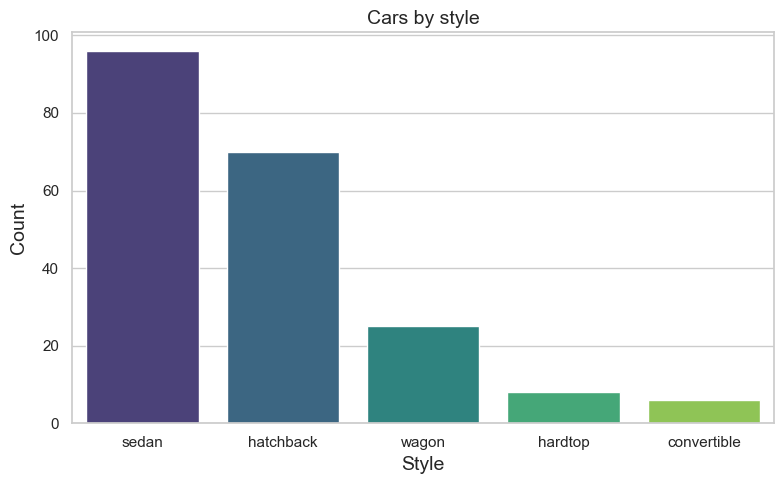

In [92]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df_clean, x='body_style', order=df_clean['body_style'].value_counts().index, palette='viridis')
plt.title('Cars by style', fontsize=14)
plt.xlabel('Style', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.tight_layout()
plt.show()


**Nhận xét:** Sedan (xe 4 cửa truyền thống) và Hatchback (xe đuôi cụt đô thị) chiếm thế thượng phong tuyệt đối trong tập dữ liệu. Đây là minh chứng rõ ràng cho thấy thị hiếu tiêu dùng những năm 80 tập trung mạnh vào tính thực dụng, trong khi các dòng xe chơi như Convertible (mui trần) hay Hardtop chỉ là những sản phẩm ngách thiểu số.

## M2.3 Price khác nhau theo body style ra sao?

C:\Users\Wingery\AppData\Local\Temp\ipykernel_6740\1456245076.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='body_style', y='price', palette='muted')


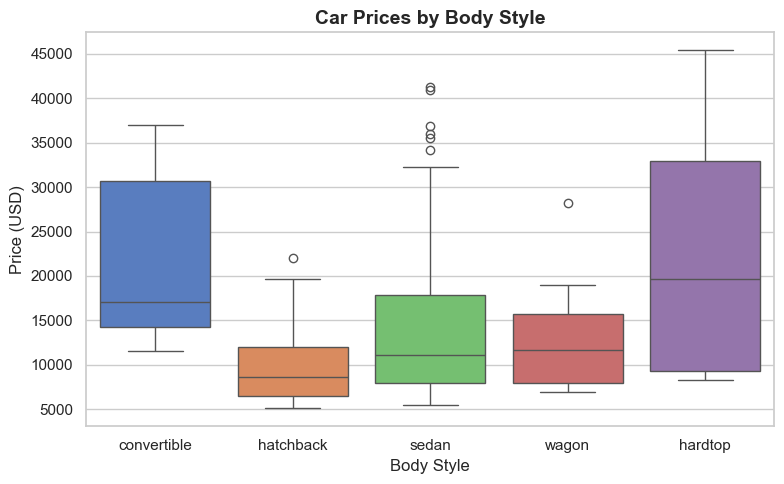

In [93]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_clean, x='body_style', y='price', palette='muted')
plt.title('Car Prices by Body Style', fontsize=14, fontweight='bold')
plt.xlabel('Body Style', fontsize=12)
plt.ylabel('Price (USD)', fontsize=12)
plt.tight_layout()
plt.show()


 xe mui trần và hardtop có giá nằm ở phân khúc cao cấp hơn hẳn phần còn lại, trong khi sedan tuy có giá trung bình  nhưng lệch nhều với nhiều outliers, nói cách khác xe sudan có dải phân khúc rộng

## M2.4 Engine size liên quan thế nào tới price?

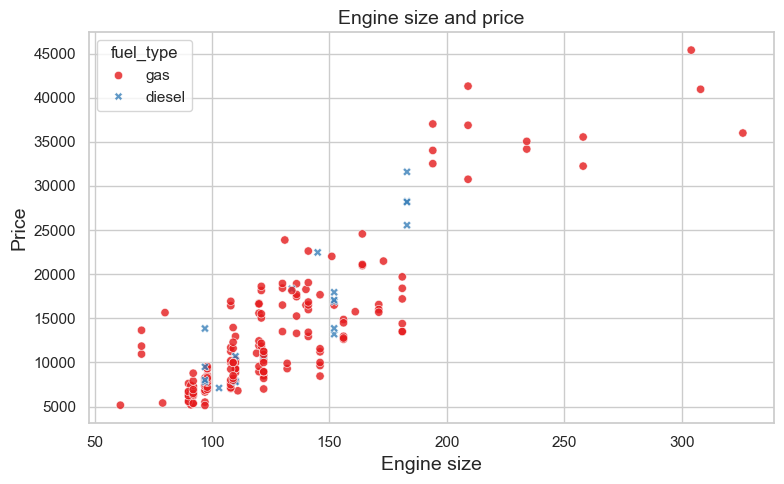

In [94]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_clean, x='engine_size', y='price', hue='fuel_type', style='fuel_type', palette='Set1', alpha=0.8)
plt.title('Engine size and price', fontsize=14)
plt.xlabel('Engine size', fontsize=14)
plt.ylabel('Price', fontsize=14)
plt.tight_layout()
plt.show()



dễ thấy động cơ càng to thì giá thành càng cao. ta thấy xe diesel có động cơ cỡ trung nhưng lại có nhiều thành phần có giá cao bất thường (> 25000). trong khi đó xe xăng ổn định hơn với lựa chọn từ rẻ tới đắt tiền với đa số là xe có giá thành rẻ và động cơ cỡ nhỏ - vừa

## M2.5 Các feature numeric tương quan ra sao?

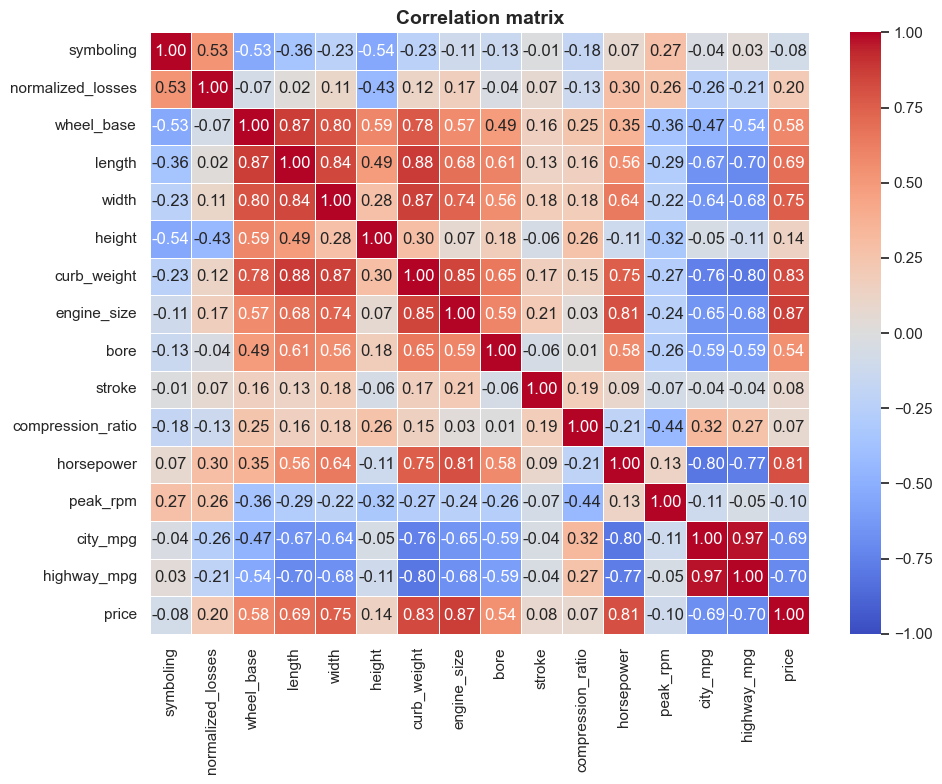

In [95]:
plt.figure(figsize=(10, 8))
corr_matrix = df_clean[NUMERIC_COLUMNS].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Correlation matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


ta thấy curb_weight và engine_size có corr là 0.85 và có horse_power là 0.81, điều này cho thấy xe càng nặng và động cơ càng lớn thì xe cáng khỏe. ngược lại thì nó tiêu tốn năng lượng nhiều hơn (-0.80, -0.76, ..) và đắt hơn 

ngược lại thì các xe có curb_weight và engine_size corr thấp thì mã lực thấp nhưng bù lại xe chạy mượt hơn trên cao tốc và giá thành cũng rẻ hơn 

## M2.6 Biểu đồ tự chọn

Đặt một câu hỏi mới, chọn chart phù hợp và không lặp nguyên năm biểu đồ trên.

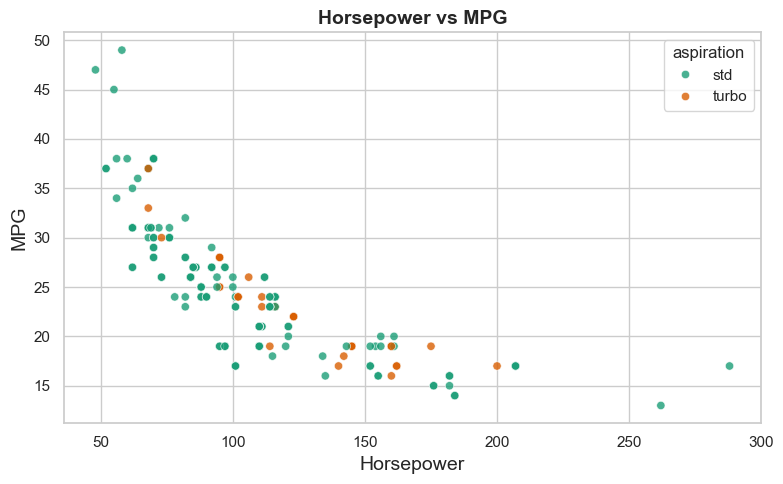

In [96]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_clean, x='horsepower', y='city_mpg', hue='aspiration', palette='Dark2', alpha=0.8)
plt.title('Horsepower vs MPG', fontsize=14, fontweight='bold')
plt.xlabel('Horsepower', fontsize=14)
plt.ylabel('MPG', fontsize=14)
plt.tight_layout()
plt.show()




đơn giản là horsepower càn cao MPG càng giảm. xe turbo tối ưu công suất mang lại horsepower lớn mà MPG không giảm quá sâu, trong khi xe std lại thua khi ta so cùng mức công suất. VD khi ở mức 170 horsepower, ta thấy chấm vàng cao hơn hẳn chấm xanh

# Tổng hợp

Viết:

- 3--5 phát hiện chính có dẫn chứng;
- ít nhất 2 hạn chế của dataset;
- một ví dụ về correlation không đồng nghĩa causation;
- một câu hỏi nên phân tích tiếp.

### phát hiện

**1**
- Xe càng có kích thước lớn, động cô mạnh thì giá thành sẽ cao (corr > 0.8)
- Mã lực tăng thì MPG giảm và có xu hướng giảm tuyến tính
- Sedan và Hatchback thông dụng nhất, convertible và hardtop thì đắt nhất
- xe diesel thì phổ biến nhất, có độ ổn định tốt nhất với kích thước động cơ trải từ nhỏ tới lớn. trong khi đó xe std thì độ ổn không nhất quán, xe phổ biến ở phân khúc tầm trung

**2**
-  205 mẫ dẫn tới dataset rất dễ bị ảnh hưởng từ outlier
- normalized_losses thiếu đến 20% làm giảm độ tin cậy khi muốn đánh giá kinh tế của xe.

**3**
- Xe nặng = giá cao. Tuy nhiên ngoài thực tế xe có thể vát thêm đồ như gạch hay đồ gia dụng, điều này dẫn tới việc giá trị của xe không hề tăng lên trong khi xe nặng hơn

**4**
- chúng ta nên phân nhóm hãng xe (so xe nhật vs xe đức)
- so công nghệ có trên xe (camera 360 với xe không có)
- độ bền của xe khi lái ở các quãng đoườgn lớn
